# Goals

- Analyze the COMPAS predictions using your logistic regression model and a GAM from a package
- Train your own models to predict recidivism your logistic regression model with the different options you built into it and a GAM from a package
- Repeat this analysis with the shuttle dataset and observe how the different models perform

# Section 1: Process and analyze the COMPAS data

## Read in the COMPAS data and process it

Read in the COMPAS dataset from this link: https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv  using Pandas and process it as follows.

1. Drop rows where all of the following apply:
   - days_b_screening_arrest <= 30
   - days_b_screening_arrest >= -30
   - is_recid != -1
   - c_charge_degree != '0'
   - score_text != 'N/A'
(This is the preprocesing used here: https://fairlens.readthedocs.io/en/latest/user_guide/compas.html)

2. Extract the following columns:
   - sex
   - age
   - race
   - juv_fel_count
   - juv_misd_count
   - juv_other_count
   - priors_count
   - c_charge_degree
   - score_text
   - two_year_recid
   - decile_score
  
3. Drop rows with any NaNs

4. Separate all 3 labels we'll use from the features: 'two_year_recid' for the true_label analysis, 'score_text' for the COMPAS analysis, and 'decile_score' to replicate a figure from the paper.

5. Onehot encode binary and categorical columns: sex, c_charge_degree, and race.  For binary features, make sure to drop one of the 2 columns.  You might consider using panda's get_dummies function.

6. Extract the feature matrix X as a numpy array and save the corresponding list of feature names.

7. Extract 3 sets of labels: (1) the compas labels compas_y (score_text), (2) the true_labels true_y (two_year_recid), and (3) the risk decile scores (decile_score) as numpy arrays.  For compas_y, the label should be 1 if score_text is 'High' and 0 o.w.  Save a list of label names to use for visualizing your models.  Consider using: compas_label_names = [ 'Lower risk' , 'High risk' ] and true_label_names = [ 'No-2yr-Recid' , '2yr-Recid' ]  You will only use decile scores for viualizing the distribution of risk deciles.

8. Preprocess your data by making a train/valid/test split and by standard scaling the features.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Loading data
link = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
compas_dataset = pd.read_csv(link)

# 1 - keeping rows
compas_conditions = compas_dataset[
    (compas_dataset['days_b_screening_arrest'] <= 30) &
    (compas_dataset['days_b_screening_arrest'] >= -30) &
    (compas_dataset['is_recid'] != -1) &
    (compas_dataset['c_charge_degree'] != '0') &
    (compas_dataset['score_text'] != 'N/A')
]

# 2 - Extracting columns
compas_columns = ['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count',
                  'priors_count', 'c_charge_degree', 'score_text', 'two_year_recid', 'decile_score']

compas_conditions = compas_conditions[compas_columns]

# 3 - Dropping rows with any NaNs
compas_conditions = compas_conditions.dropna()

# 4 - Ensuring consistent row alignment across features and labels
compas_y = np.where(compas_conditions['score_text'] == 'High', 1, 0)  # COMPAS labels (use for prediction)
true_y = compas_conditions['two_year_recid'].values  # True labels
risk_decile_score = compas_conditions['decile_score'].values  # Risk decile scores

# 5 - Onehot encode binary and categorical columns for features
compas_encoded = pd.get_dummies(compas_conditions, columns=['sex', 'c_charge_degree', 'race'], drop_first=True)

# 6 - Extracting X as a numpy array and saving the list of feature names
X = compas_encoded.drop(columns=['score_text', 'two_year_recid', 'decile_score']).values
feature_names = compas_encoded.drop(columns=['score_text', 'two_year_recid', 'decile_score']).columns.tolist()

# 7 - Preprocessing data
# Splitting data using compas_y
X_train, X_test, y_train, y_test = train_test_split(X, compas_y, test_size=0.3, random_state=7)  # Using compas_y for splitting

# 8 - Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Printing shapes and data
print("Feature matrix shape:", X.shape)
print("COMPAS labels shape:", compas_y.shape)
print("Feature names:", feature_names)


/var/folders/59/kb315h4121n8mknx9yhv95br0000gn/T/ipykernel_7224/2149168822.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Feature matrix shape: (6172, 12)
COMPAS labels shape: (6172,)
Feature names: ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'sex_Male', 'c_charge_degree_M', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']


## Replicate the Propublica Risk Deciles Analysis

Replicate the histograms of Black and White defendents' risk scores from the Propublica article.  Make sure to label your graphs.  Does it look the same as the article?  (It should if you've done the data processing correctly!)  

Link to article: https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing

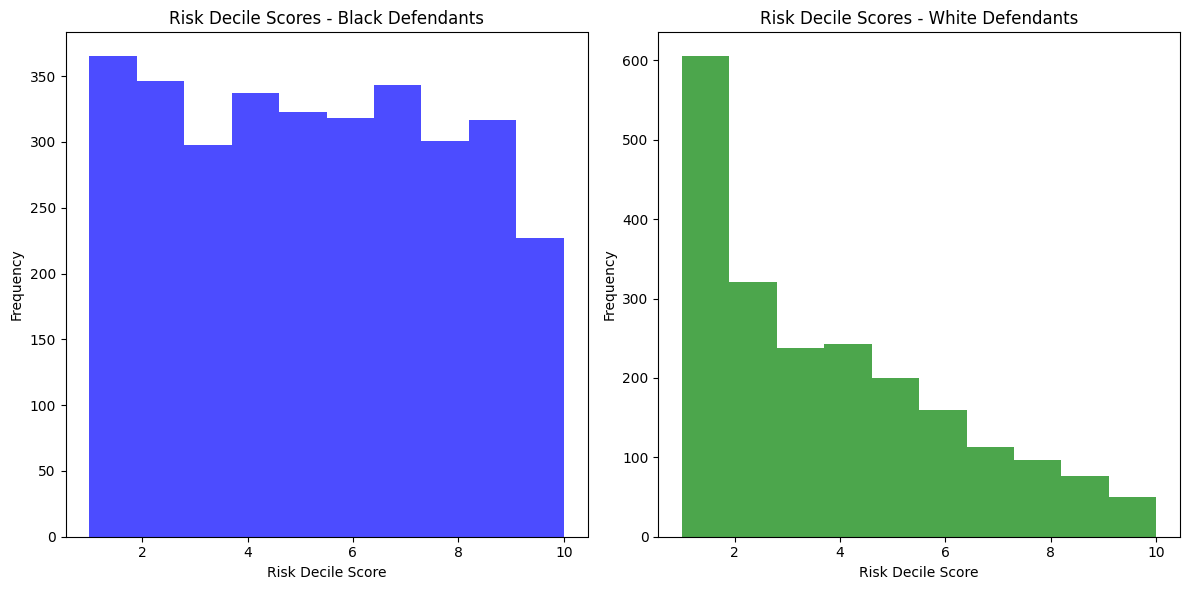

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter data using race
black_defendants = compas_conditions[compas_conditions['race'] == 'African-American']
white_defendants = compas_conditions[compas_conditions['race'] == 'Caucasian']

# Plot histograms
plt.figure(figsize=(12, 6))

# Black defendants risk decile scores
plt.subplot(1,2,1) # rows, columns, first plot in that order
plt.hist(black_defendants['decile_score'], bins=10, range=(1, 10), color='blue', alpha = 0.7)
plt.title('Risk Decile Scores - Black Defendants')
plt.xlabel('Risk Decile Score')
plt.ylabel('Frequency')

# White defendants risk decile scores
plt.subplot(1, 2, 2) # 1 row, 2 columnsm and 2nd plot
plt.hist(white_defendants['decile_score'], bins=10, range=(1,10), color='green', alpha = 0.7)
plt.title('Risk Decile Scores - White Defendants')
plt.xlabel('Risk Decile Score')
plt.ylabel('Frequency')

# plot
plt.tight_layout()
plt.show()

# Model the COMPAS Labels

## Train a logistic regression model on the COMPAS labels and interpret the coefficients

Train your implementation of a logistic regression model with no penalty and no interaction terms (default parameters) to predict compas_y. 

Use your print_model_evaluation and plot_model_weights to evaluate your model and interpret its coefficients.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from logistic_regression import LogisticRegression  
from util import plot_model_weights, print_model_evaluation

# Splitting data using compas_y 
X_train, X_test, y_train, y_test = train_test_split(X, compas_y, test_size=0.3, random_state=7)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the Logistic Regression model
feature_names = ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'sex_Male', 'c_charge_degree_M', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']

model = LogisticRegression(feature_names=feature_names, step_size=1e-2, n_iter=5000)

# Fit the model
model.fit(X_train_scaled, y_train)  # Ensure you're passing the correct scaled training data and labels

# Evaluate & Plotting
print_model_evaluation(model, X_train_scaled, y_train, X_test_scaled, y_test)
#plot_model_weights(model, feature_names)

Fraction of positive labels in train set: 0.19
Fraction of positive labels in test set: 0.18
Train Accuracy: 0.25
Test Accuracy: 0.25
y_train_shape: (4320,), y_train_prob: (4320,)
y_test_shape: (1852,), y_test_prob: (1852,)
Train AUC: 0.83
Test AUC: 0.84


(0.24676025917926567, 0.8422460478636563)

### Writing prompt 1: Explain how this model works in 1-3 sentences (which features matter).

The model uses various features to predict the likelihood of re-offending. Utilizing the feature weights it shows that age has the biggest negative impact meaning that most re-offenders are of younger age, and prior counts have the largest positive weight so individuals with past offenses are more likely to be labeled as high risk. Other various features such as race have a negative impact on predicting re-offenders, like Native American and Other but some categories dont have much of an effect(sex and c_charge_degree_M). 

## Train a GAM

Train a LogisticGAM model to predict compas_y using the PyGAM package.  Use a spline term for each continuous feature, and a factor term for each each binary feature.  Set the number of splines to 10.  Use your print_model_evaluation function to evaluate the model.

In [4]:
from pygam import LogisticGAM, s, f
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from util import print_model_evaluation

# split data using compas_y
X_train, X_test, y_train, y_test = train_test_split(X, compas_y, test_size=0.3, random_state=7)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# seperating features
continous_features = ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count'] #first 5 features 
binary_features = ['sex_Male', 'c_charge_degree_M', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other']

# Defining model 
gam_model = LogisticGAM(
    s(0, n_splines=10) + # continuous features
    s(1, n_splines=10) + 
    s(2, n_splines=10) +
    s(3, n_splines=10) +
    s(4, n_splines=10) +
    f(5) + #binary_features
    f(6) +
    f(7) +
    f(8) +
    f(9) +
    f(10) +
    f(11)
)

# fitting model
gam_model.fit(X_train_scaled, y_train)

# evaluating model
print_model_evaluation(gam_model, X_train_scaled, y_train, X_test_scaled, y_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2


did not converge
Fraction of positive labels in train set: 0.19
Fraction of positive labels in test set: 0.18
Train Accuracy: 0.84
Test Accuracy: 0.86


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

## Interpret the GAM

Write an interpret_gam function that takes in a trained GAM model and a list of feature_names.  Your function should plot the partial dependence functions, including 95% confidence intervals, for all of the features that aren't the intercept.  

If you'd like more detail than we saw in class, you can refer to the Partial Dependence Functions section of this quick start guide: https://pygam.readthedocs.io/en/latest/notebooks/quick_start.html#Partial-Dependence-Functions 

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def interpret_gam(gam_model, feature_names):
    """
    Plots the partial dependence functions along with 95% confidence intervals 
    for each feature in the GAM model.
    
    Parameters:
    ----------
    gam_model: a trained GAM model (PyGAM LogisticGAM in this case)
    feature_names: list of feature names corresponding to the features in the model
    """
    # Loop over each feature in the model
    for i, feature in enumerate(feature_names):
        plt.figure(figsize=(8, 5))
        
        # Generate a grid of values for feature i
        XX = gam_model.generate_X_grid(term=i)
        
        # Compute partial dependence for feature i
        partial_dep = gam_model.partial_dependence(term=i, X=XX)
        
        # Compute confidence intervals for feature i
        confidence_intervals = gam_model.partial_dependence(term=i, X=XX, width=0.95)
        
        # Flattening confidence intervals to 1D arrays
        lower_bound = np.ravel(confidence_intervals[0]) #class 0
        upper_bound = np.ravel(confidence_intervals[1]) #class 1
        
        # checking bounds have same length and if not then upper_bound is sliced
        if len(lower_bound) != len(upper_bound):
            upper_bound = upper_bound[:len(lower_bound)]
        
        # Plot the partial dependence
        plt.plot(XX[:, i], partial_dep, label=f'Partial dependence for {feature}', color='blue')
        
        # Plot the confidence intervals
        plt.fill_between(XX[:, i], lower_bound, upper_bound, color='gray', alpha=0.3, label='95% Confidence Interval')
        
        # Add titles and labels
        plt.title(f'Partial Dependence of {feature}')
        plt.xlabel(f'{feature}')
        plt.ylabel('Predicted Probability')
        plt.legend()
        plt.grid(True)
        
        # Show the plot
        plt.show()

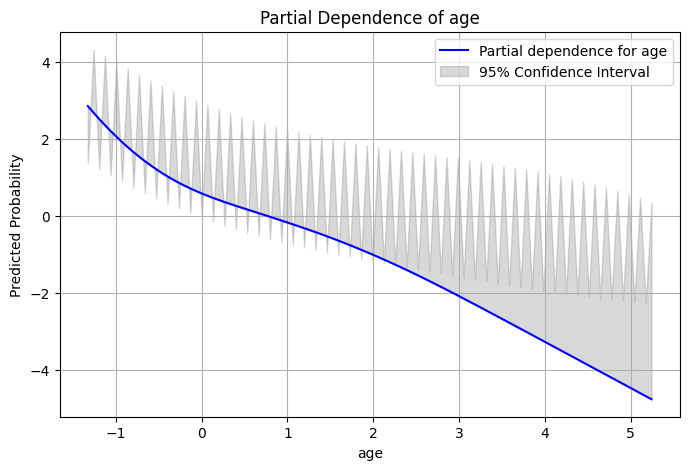

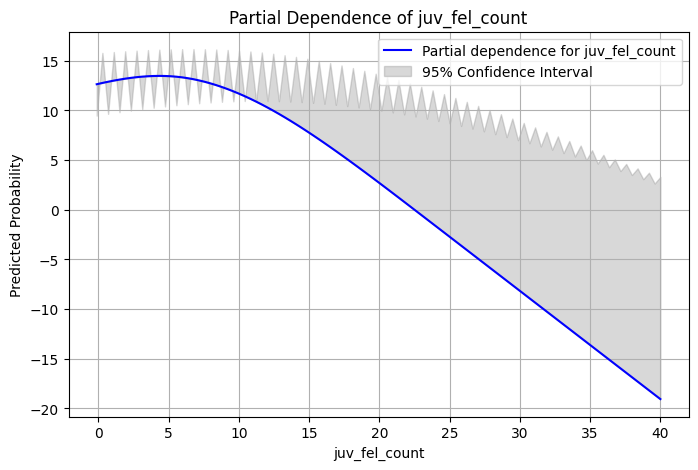

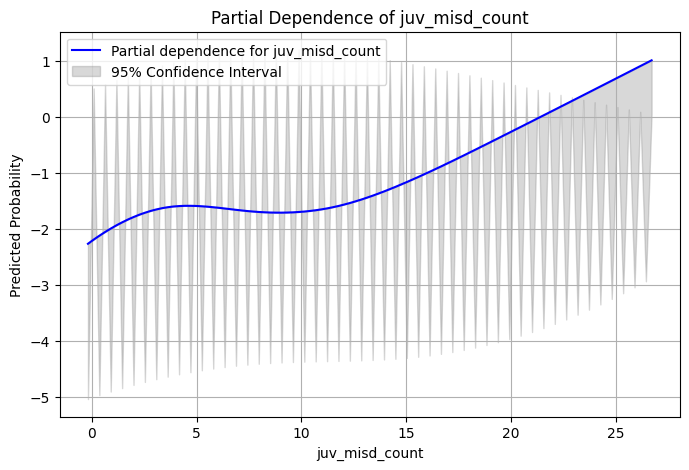

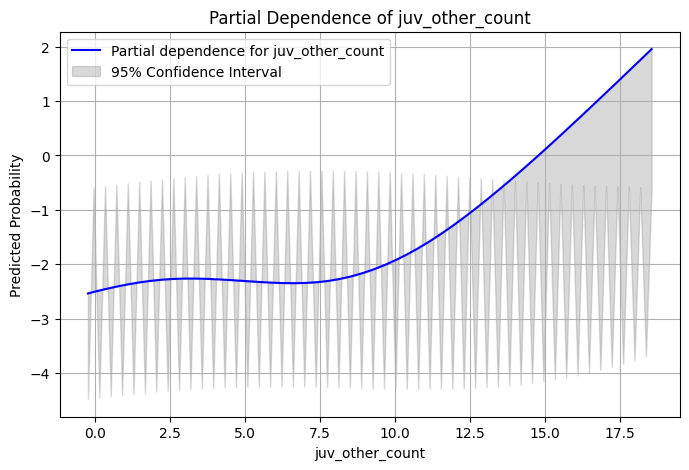

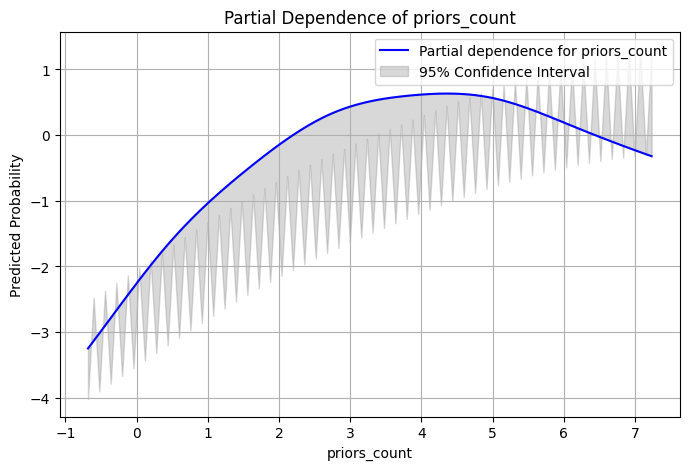

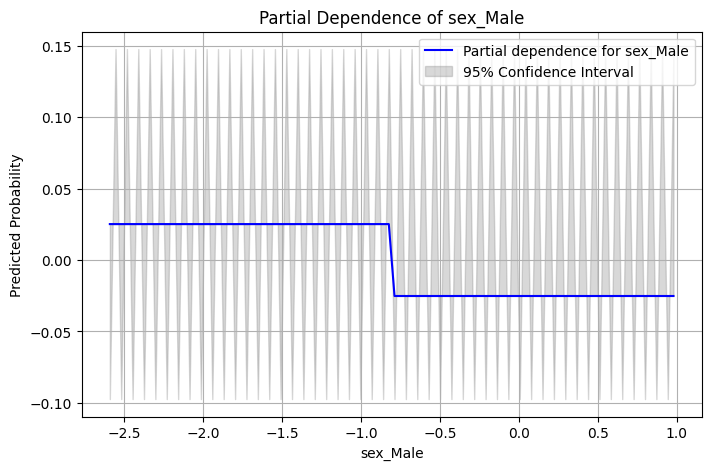

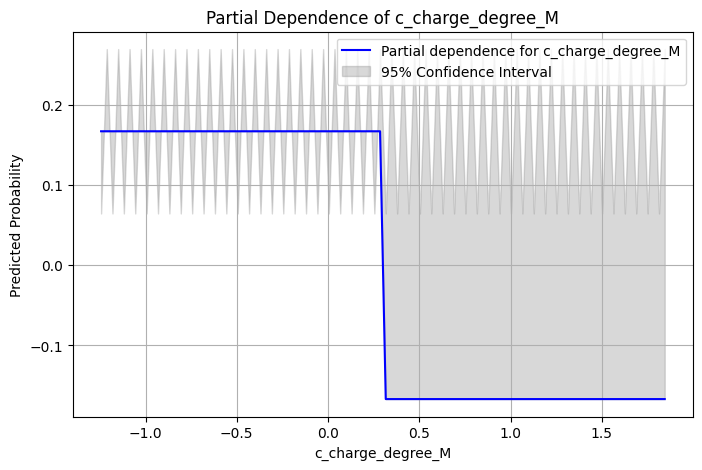

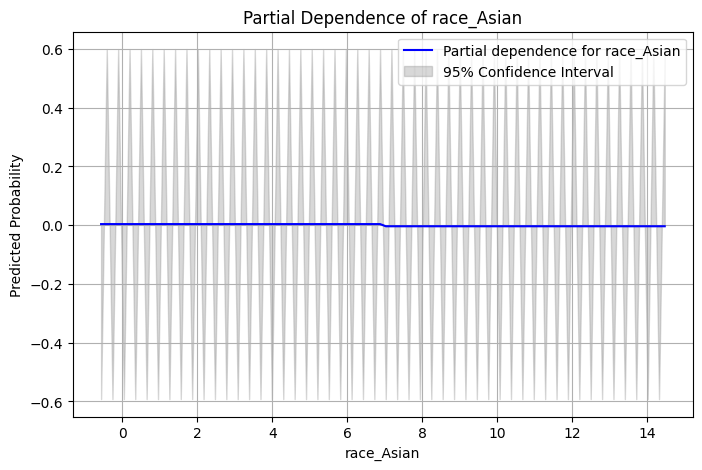

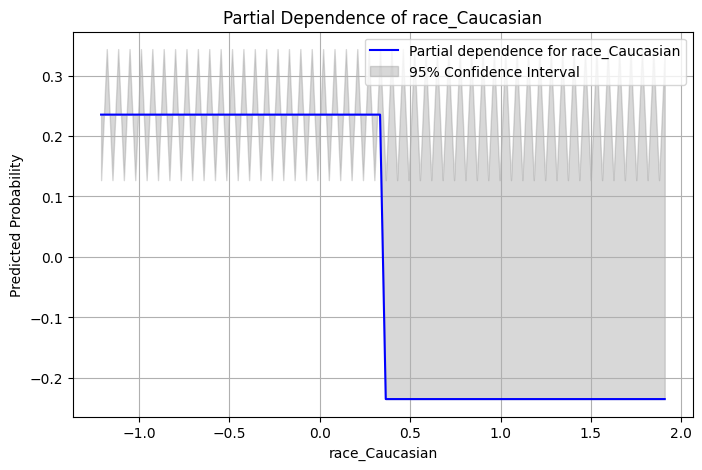

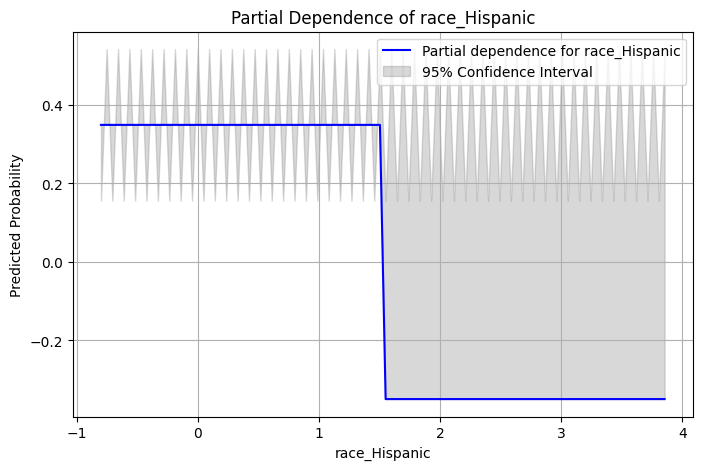

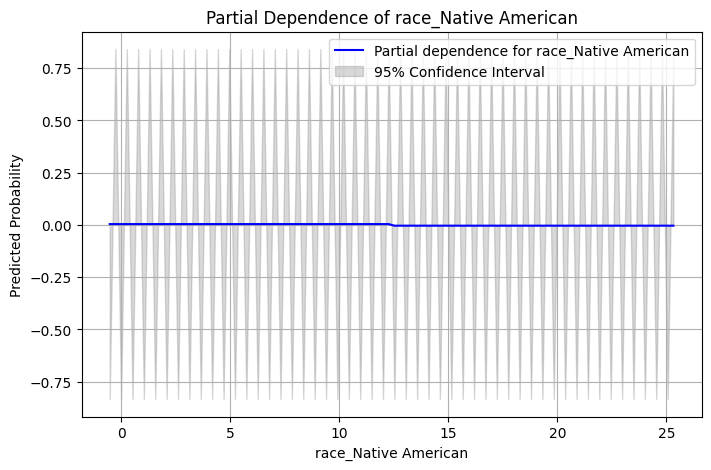

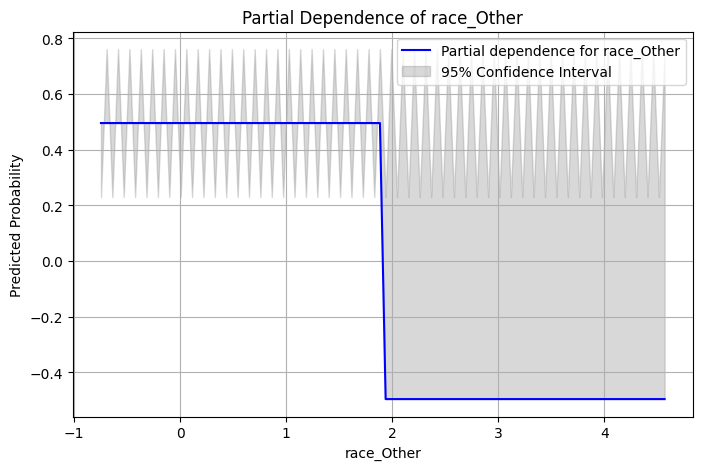

In [7]:
interpret_gam(gam_model, feature_names)

### Writing prompt 2: Explain how this model works in 1-3 sentences.  Focus on how features contribute to the predictions.

This model predicts criminals reoffending by analysizing various features such as age, race, and prior offenses. There are features with positive weights such as prior offenses that increase the chance of reoffending and there are also negative features that reduce the likelihood such as age. The model uses logistic regression to utilize the weights and try to estimate the likelihood of reoffending using the feature inputs

### Writing prompt 3: How does the COMPAS algorithm work?  Focus on how features appear to contribute to COMPAS predictions.

COMPAS algorithim predicts the chance of criminals reoffending by analyzing individual features(criminal history, demographic data, and other factos). Some features have more of an influence to impact the risk score like prior offense, while some may have bias in making predictions like race. Using these features COMPAS tries to generate a risk score to showcase who would have a higher chance to reoffend.

# Section 2: Model the true labels

## Train logistic regression on the true recidivism labels and interpret the coefficients

Train your logistic regression model on the true labels--true_y with no penalty and no interaction terms (default parameters).

Use your print_model_evaluation and plot_model_weights to evaluate your model and interpret its coefficients.

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from logistic_regression import LogisticRegression
from util import print_model_evaluation, plot_model_weights

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, true_y, test_size=0.3, random_state=7)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logisitic regression model
feature_names = ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count',
                 'sex_Male', 'c_charge_degree_M', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 
                 'race_Native American', 'race_Other']

model = LogisticRegression(feature_names=feature_names, step_size=1e-2, n_iter=5000, penalty=None, interactions=False)
model.fit(X_train_scaled, y_train)

# Evaluating model
print_model_evaluation(model, X_train_scaled, y_train, X_test_scaled, y_test)

# Plot weights
#plot_model_weights(model, feature_names)

Fraction of positive labels in train set: 0.46
Fraction of positive labels in test set: 0.45
Train Accuracy: 0.46
Test Accuracy: 0.45
y_train_shape: (4320,), y_train_prob: (4320,)
y_test_shape: (1852,), y_test_prob: (1852,)
Train AUC: 0.73
Test AUC: 0.71


(0.4481641468682505, 0.7060812722514324)

## Train the sparsest logistic regression model you can without harming predictive performance

Fit the sparsest logistic regression model you can (fewest non-zero coefficients) on true_y that has an AUC within 0.01 of your model in the previous step.  You should use an l1 penalty and explore alphas on a log-10 scale (e.g. 0.001, 0.01, 0.1 etc).  

You can assume that features that appear very small in your visualization are functionally zero.  

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from logistic_regression import LogisticRegression
from util import print_model_evaluation, plot_model_weights

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, true_y, test_size=0.3, random_state=7)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# implementing L1 regularization and alpha values
alphas = [0.001, 0.01, 0.1]
best_model = None
best_auc = 0
best_alpha = None
sparset_weights = None

# Tracking original model AUC
orginal_model_auc = 0.71

for alpha in alphas:
    print(f"Training with alpha={alpha}")
    #Model w/ L1 penalty
    model = LogisticRegression(feature_names=feature_names, step_size=1e-2, n_iter=5000, penalty='l1', alpha=alpha, interactions=False)
    model.fit(X_train_scaled, y_train)
    
    #Evaluating model
    print(f"Evaluating model with alpha={alpha}")
    auc = print_model_evaluation(model, X_train_scaled, y_train, X_test_scaled, y_test)
    
    # Determine if AUC is within 0.01
    if auc >= orginal_model_auc - 0.01:
        non_zero_weights = np.sum(model.weights != 0) # counting # of non-zero coef.
        print(f"Model with alpha={alpha} has {non_zero_weights} non-zero coefficients")
        
        if best_model is None or non_zero_weights < np.sum(sparset_weights != 0): #tracking best sparset model that meets criteria for AUC
            best_model = model
            best_auc = auc
            best_alpha = alpha
            sparset_weights = model.weights

# Evaluating model
if best_model is not None:
    print(f"Best alpha: {best_model}")
    print(f"Best AUC: {best_auc}")
    plot_model_weights(best_model, feature_names)
else:
    print("No model found within the AUC threshold")


Training with alpha=0.001
Evaluating model with alpha=0.001
Fraction of positive labels in train set: 0.53
Fraction of positive labels in test set: 0.52
Train Accuracy: 0.53
Test Accuracy: 0.52
Train AUC: 0.71
Test AUC: 0.65
Training with alpha=0.01
Evaluating model with alpha=0.01
Fraction of positive labels in train set: 0.53
Fraction of positive labels in test set: 0.52
Train Accuracy: 0.53
Test Accuracy: 0.52
Train AUC: 0.52
Test AUC: 0.49
Training with alpha=0.1
Evaluating model with alpha=0.1
Fraction of positive labels in train set: 0.53
Fraction of positive labels in test set: 0.52
Train Accuracy: 0.53
Test Accuracy: 0.52
Train AUC: 0.53
Test AUC: 0.53
No model found within the AUC threshold


## Now fit a model with interaction terms and no sparsity penalty

Fit your logistic regression model on true_y with no penalty and with interaction terms.  Evaluate it and visualize its weights.  

Fraction of positive labels in train set: 0.53
Fraction of positive labels in test set: 0.52
Train Accuracy: 0.53
Test Accuracy: 0.52
Train AUC: 0.75
Test AUC: 0.61


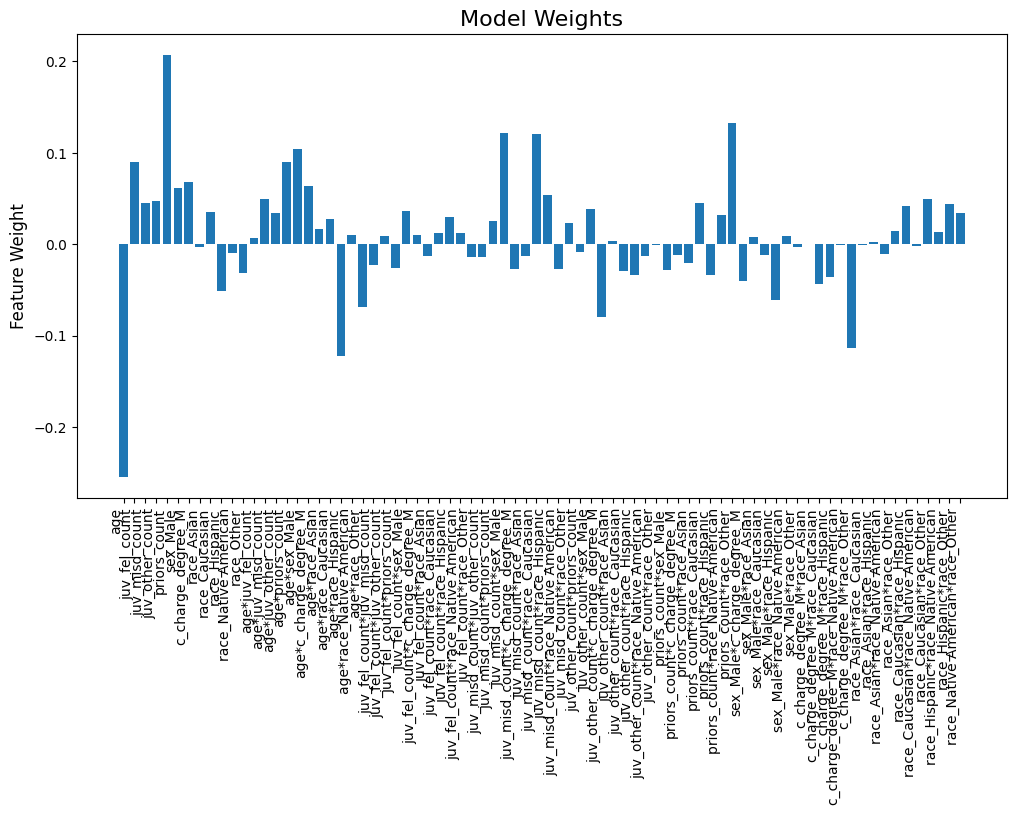

In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from util import print_model_evaluation, plot_model_weights
from logistic_regression import LogisticRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, true_y, test_size=0.3, random_state=7)

# Scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model w/ interaction terms and no sparsity penalty
model_interactions = LogisticRegression(feature_names=feature_names, step_size=1e-2, n_iter=5000, penalty=None, interactions=True)

# Fitting model
model_interactions.fit(X_train_scaled, y_train)

# Evaluating model
print_model_evaluation(model_interactions, X_train_scaled, y_train, X_test_scaled, y_test)

# Visualize model
plot_model_weights(model_interactions, feature_names)

## Fit a model with a sparsity penalty on only the interaction terms

Fit your logistic_regression model on true_y with interaction terms, no penalty on the non-interaction terms, and interaction_alpha=0.01 l1 penalty on the interaction terms.

Fraction of positive labels in train set: 0.53
Fraction of positive labels in test set: 0.52
Train Accuracy: 0.53
Test Accuracy: 0.52
Train AUC: 0.75
Test AUC: 0.61


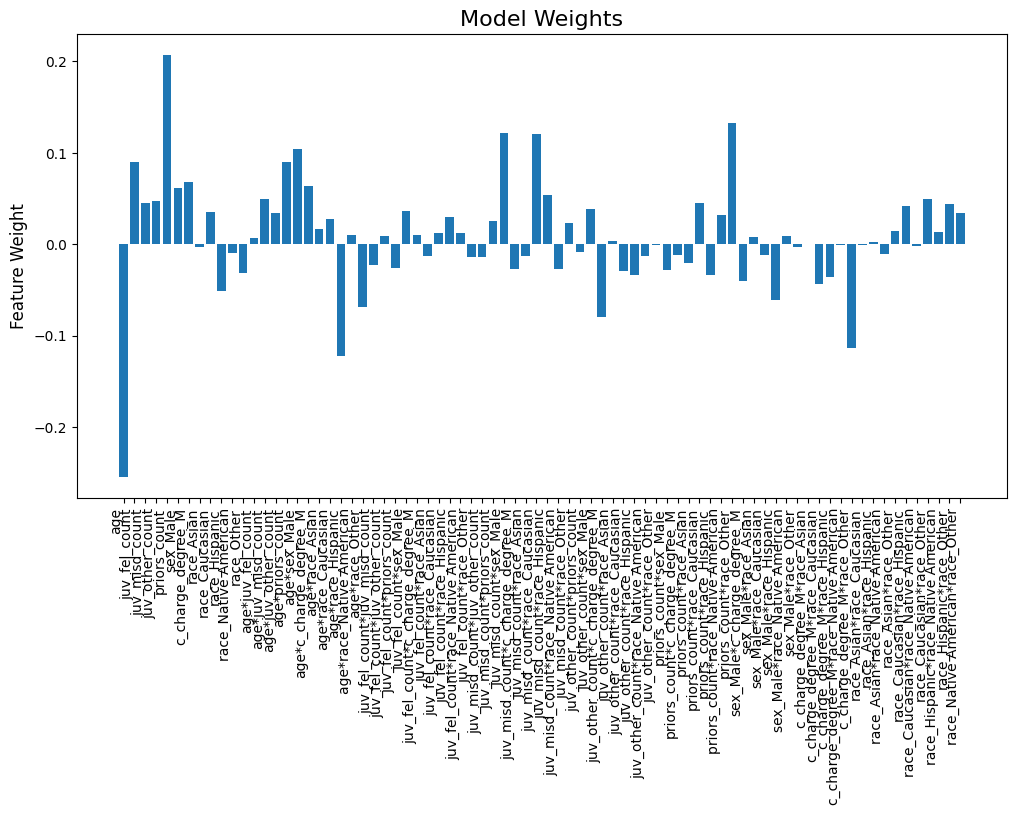

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from util import print_model_evaluation, plot_model_weights
from logistic_regression import LogisticRegression

# splitting data: train & test 
X_train, X_test, y_train, y_test = train_test_split(X, true_y, test_size=0.3, random_state=7)

# Scale data
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

# Train model with interaction terms, no penalty on the non-interaction terms, and interaction_alpha=0.01 l1 penalty on the interaction terms.
model_sparisity_iteractions = LogisticRegression(feature_names=feature_names, step_size=1e-2, n_iter=5000,penalty=None, interactions=True, interaction_alpha=0.01) # L1 penalty on interaction terms 

# fit model
model_sparisity_iteractions.fit(X_train_scaled, y_train)

# Evaluating model
print_model_evaluation(model_sparisity_iteractions, X_train_scaled, y_train, X_test_scaled, y_test)

# plot model weights
plot_model_weights(model_sparisity_iteractions, feature_names)

## Train and interpret a GAM 

Train a LogisticGam model using the PyGAM package on true_y.  Use a spline term for each continuous feature, and factor term for each each binary feature.  Set the number of splines to 10.  Use your print_model_evaluation function to evaluate the model.  Use your interpret_gam function to visualize how your gam works.


Fraction of positive labels in train set: 0.53
Fraction of positive labels in test set: 0.52
Train Accuracy: 0.68
Test Accuracy: 0.63
Train AUC: 0.75
Test AUC: 0.69


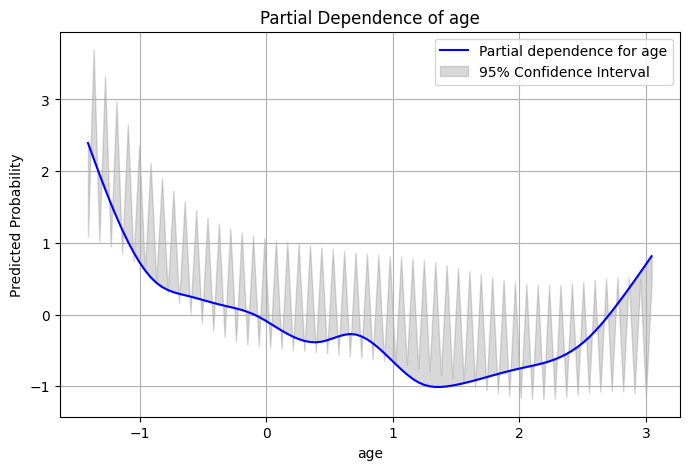

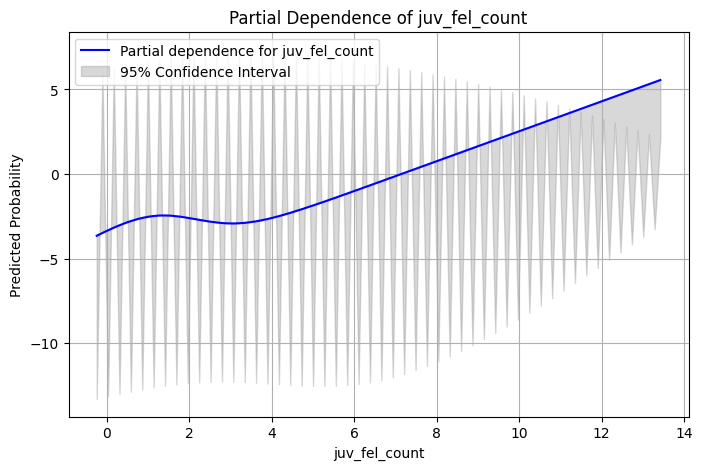

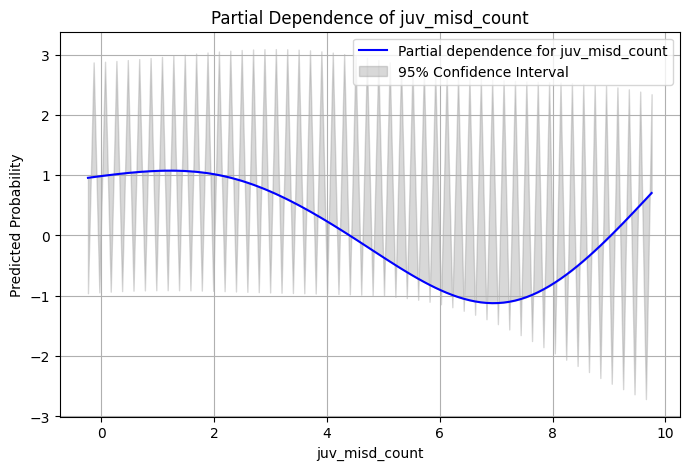

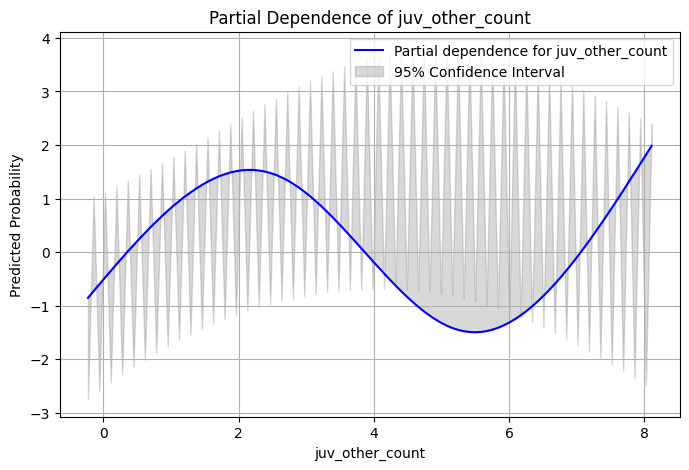

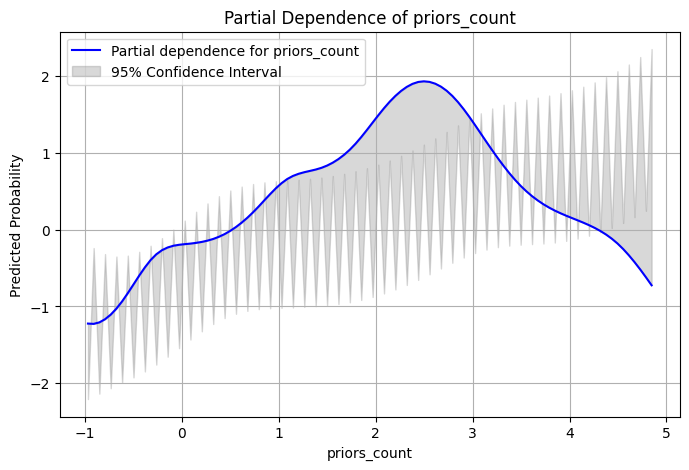

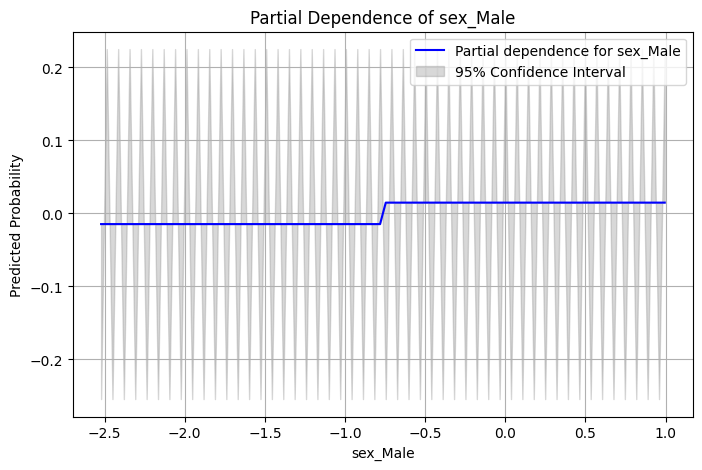

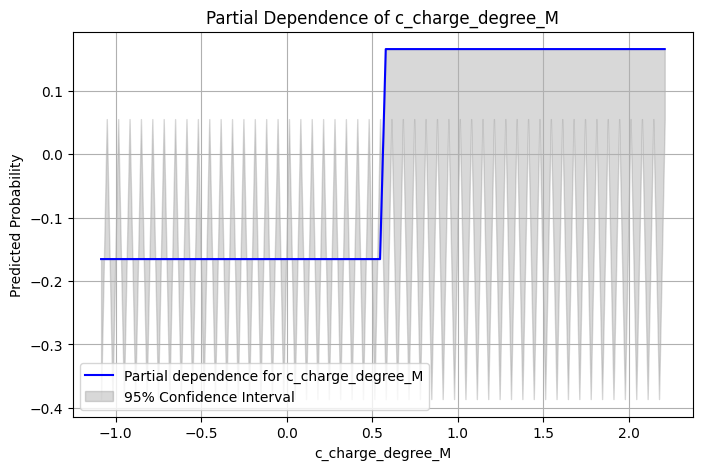

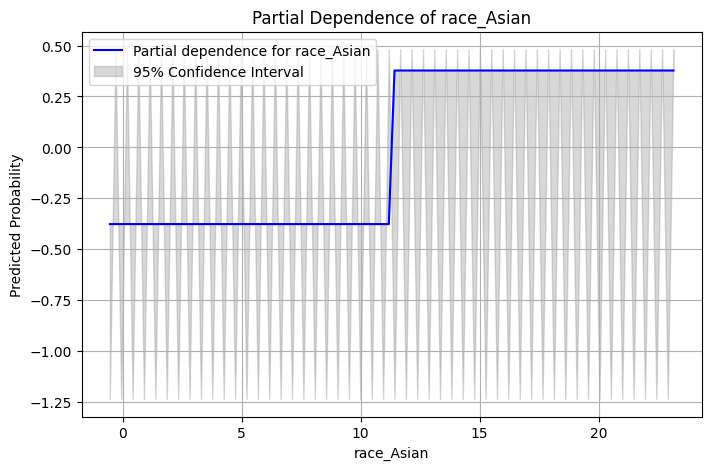

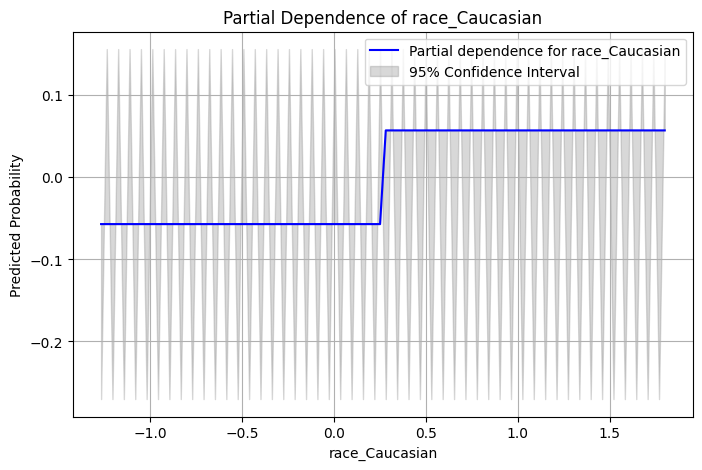

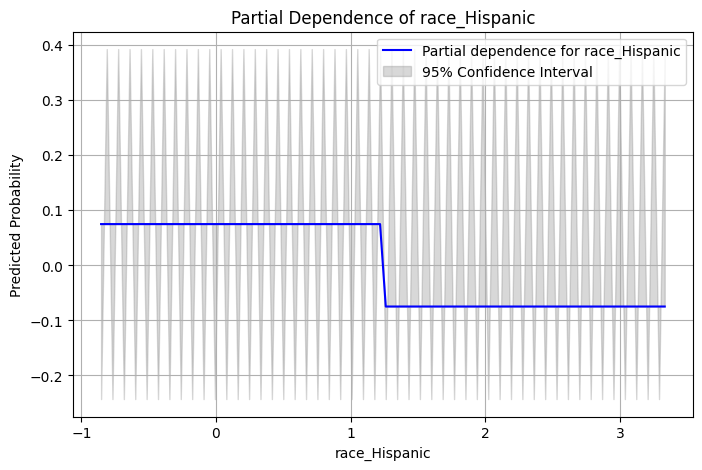

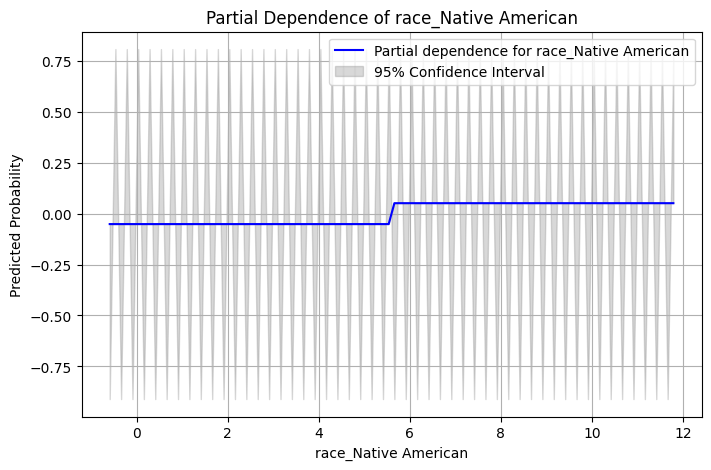

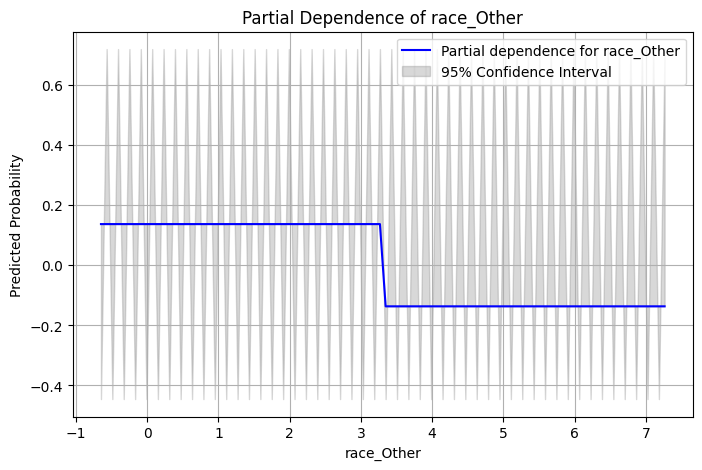

In [12]:
from pygam import LogisticGAM, s, f
import numpy as np
import matplotlib.pyplot as plt

#  Splitting features into continuous and binary
continous_features = ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count']
binary_features = ['sex_Male', 'c_charge_degree_M', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other'] 

# logisticGam model w/ splines for continuous featuers, and for binary features using factor terms
terms = (
    s(0) + s(1) + s(2) + s(3) + s(4) +  # Splines for continuous features
    f(5) + f(6) + f(7) + f(8) + f(9) + f(10) + f(11)  # Factor terms for binary features
)

# train model
gam_model = LogisticGAM(terms).fit(X_train_scaled, y_train)

# Evaluating model
print_model_evaluation(gam_model, X_train_scaled, y_train, X_test_scaled, y_test)

# visualizing the model
interpret_gam(gam_model, feature_names)

## Writing prompt 4: Which model do you recommend using and why?

I would recommend using the GAM model because the interprebility of the GAM models are better since they are able to determine how individual features are able to contribute to the predictions through the use of partial dependence plots. The GAM model has both interprebility and preidictive accuracy that will ensure in a great understanding of the topic at hand, the proability of a criminal reoffending. 

# Replicate this Analysis with UCI Shuttle dataset  

You will follow all the same steps from above to compare the same models on a new dataset.  You may find that you prefer different models on this data.

## Read in and preprocess the data 

Read in the UCI Shuttle dataset from the supplied shuttle.csv file using pandas.  

Extract the features as a numpy array--X, and the labels as a numpy array--y.  The labels are in the "label" column and all of the other columns are features.  Save the feature names as a list to use when explaining your models.

Preprocess your data by making a train/valid/test split and by standard scaling the features.

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#loading dataset
dataset = 'shuttle.csv'
shuttle_dataset = pd.read_csv(dataset)

#Seperating features(X) and labels(y)
X = shuttle_dataset.iloc[:, :-1] #extracting all except last column
y = shuttle_dataset.iloc[:, -1] #last column

#splitting into numeric and categorical pipelines
numeric_features = X.select_dtypes(exclude=['object']).columns # every numeric column
categorical_features = X.select_dtypes(include=['object']).columns # every colunmn that isnt numeric

# applying scaling to numeric features and encoding to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'  # Leave the rest of the columns untouched
)

#split data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=7)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=7)

# Fit data using preprocessing
X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

#checking shapes
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (3500, 7)
X_val_scaled shape: (750, 7)
X_test_scaled shape: (750, 7)


## Run the same models as in Section 2 on the Shuttle dataset

You should train, evaluate, and generate an explanation for the following models.  (You can expect the code to be practically identical to section 2, but the results will be quite different).   
- Default logistic regression model
- Sparsest logistic regression with AUC within 0.01 of model 1
- Logistic regression with interaction terms (and default parameters for everything else)
- Logistic regression with interaction terms and l1 penalty on the interaction-terms-only with alpha=0.01
- GAM with spline terms for each continuous features, factor terms for each each binary feature, and 10 splines.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# training default logistic regression model
default_logistic_model = LogisticRegression(max_iter=1000, random_state=7)
default_logistic_model.fit(X_train_scaled, y_train)

# Evaluating model
y_train_pred = default_logistic_model.predict(X_train_scaled)
y_test_pred = default_logistic_model.predict(X_test_scaled)

default_train_auc = roc_auc_score(y_train, default_logistic_model.predict_proba(X_train_scaled)[:, 1])
default_test_auc = roc_auc_score(y_train, default_logistic_model.predict_proba(X_train_scaled)[:, 1])

print(f"Default Logistic Regression: Train AUC: {default_train_auc}, Test AUC: {default_test_auc}")

Default Logistic Regression: Train AUC: 0.8909608843537415, Test AUC: 0.8909608843537415


In [21]:
alphas = [0.001, 0.01, 0.1, 1.0]
best_model = None

for alpha in alphas:
    model_l1 = LogisticRegression(penalty='l1', solver = 'saga', C=1/alpha, max_iter=5000, random_state=7)
    model_l1.fit(X_train_scaled, y_train)
    
    train_auc = roc_auc_score(y_train, model_l1.predict_proba(X_train_scaled)[:, 1])
    test_auc = roc_auc_score(y_test, model_l1.predict_proba(X_test_scaled)[:, 1])
    
    #making sure auc is within 0.01 of default model's auc
    if abs(train_auc - default_train_auc) <= 0.01:
        best_model = model_l1
        print(f"Selected model with alpha={alpha}: Train AUC: {train_auc}, Test AUC: {test_auc}")
        break

Selected model with alpha=0.001: Train AUC: 0.88993379494655, Test AUC: 0.8855994662446275


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [23]:
from sklearn.preprocessing import PolynomialFeatures

# Interaction terms 
interaction = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_interactions = interaction.fit_transform(X_train_scaled)
X_test_interactions = interaction.transform(X_test_scaled)

#Training model w/ interactions
model_interactions = LogisticRegression(max_iter=5000, random_state=7)
model_interactions.fit(X_train_interactions, y_train)

# Evaluating model
train_auc_interactions = roc_auc_score(y_train, model_interactions.predict_proba(X_train_interactions)[:, 1])
test_auc_interactions = roc_auc_score(y_test, model_interactions.predict_proba(X_test_interactions)[:, 1])

print(f"Model with Interaction Terms: Train AUC: {train_auc_interactions}, Test AUC: {test_auc_interactions}")

Model with Interaction Terms: Train AUC: 0.9985975461613217, Test AUC: 0.9965398997657061


In [25]:
# Model with interactions terms and L1 penalty
model_interactions_l1 = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, random_state=7)
model_interactions_l1.fit(X_train_interactions, y_train)

# Evaluating model
train_auc_interactions_l1 = roc_auc_score(y_train, model_interactions_l1.predict_proba(X_train_interactions)[:, 1])
test_auc_interactions_l1 = roc_auc_score(y_test, model_interactions_l1.predict_proba(X_test_interactions)[:, 1])

print(f"Model with Interaction Terms and L1 Penalty: Train AUC: {train_auc_interactions_l1}, Test AUC: {test_auc_interactions_l1}")

Model with Interaction Terms and L1 Penalty: Train AUC: 0.9369248056365402, Test AUC: 0.9290291548356063


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [30]:
from pygam import LogisticGAM, s, f

#Spline & Factor terms
terms = s(0) + s(1) + s(2) + s(3) + s(4)  # Splines for continuous features
terms += f(5) + f(6)  # Factor terms for binary features
    
# training GAM model
gam_model = LogisticGAM(terms).fit(X_train_scaled, y_train)

# Evaluating model
train_auc_gam = roc_auc_score(y_train, gam_model.predict_proba(X_train_scaled))
test_auc_gam = roc_auc_score(y_test, gam_model.predict_proba(X_test_scaled))

print(f"GAM Model: Train AUC: {train_auc_gam}, Test AUC: {test_auc_gam}")

GAM Model: Train AUC: 0.9998189990281827, Test AUC: 0.9903334419463452


## Writing prompt 5: Which model, between the GAM and the model with interaction terms and no sparsity penalty, is more interpretable?  Why?  Respond in 2-4 sentences.  We will do an exercise based on this in class.

The GAM model is more interpretable because GAM allows for a better visualization of the partial dependence of each feature while still being able to get a hold of nonlinear relationships resulting in a better understanding of how each features affects the outcome. However, the interaction model is much more difficult to interpret and does not help that its more complex with interaction terms since it complicates the understanding of individual features affecting the predictions.

### Extension Ideas:
- Include additional feature transformation terms in your logistic regression model.  Consider adding different penalties for different terms.  E.g. perhaps interaction terms are harder to interpret than log-transformed terms and so should have a higher penalty, but terms with no transformation are easier than log terms so should have a lower penalty.
- Explore the PyGAM package.  Can you fit a GAM that models the shuttle data just as well but is easier to interpret?  Consider using different types of terms, or different options within the terms.
- Compare your GAM model on the shuttle dataset to a neural network trained on the same dataset and explained using LIME.  Which is more interpretable?  Which explanation do you trust more?
- Construct and describe a toy dataset that can only be modeled accurately by a GAM and not a logistic regression model.  Show that this is the case by fitting both models.
- Construct and describe a toy dataset can be more accurately modeled by a GAM than a logistic regression model with interaction terms, or vice versa.  Show that this is the case by fitting both models.